# 03 - Tiền Xử Lý Dữ Liệu Chuyên Sâu (Data Preprocessing Pipeline)
### Dự án: Dự Báo Lượng Mưa Cực Ngắn (Rainfall Nowcasting) tại Việt Nam
---

Notebook này xây dựng đường ống tiền xử lý dữ liệu (Preprocessing Pipeline) chuẩn công nghiệp, tối ưu hoá bộ nhớ RAM (Memory-Efficient), chống rò rỉ dữ liệu (Data Leakage Prevention) và sẵn sàng cấp phát cho các mô hình học sâu Spatiotemporal (ConvLSTM, PredRNN, Earthformer, ThoR PINN, Diffusion).

### Các điểm cải tiến & chuẩn mực kỹ thuật trong Pipeline:
1. **Tránh Rò rỉ Dữ liệu (No Data Leakage):**
   - Các tham số chuẩn hoá (Min, Max, Mean, Std, Log-scaling) **CHỈ được tính toán trên Tập Huấn luyện (Train set: 2023 - 2024)**, sau đó áp dụng sang Tập Validation và Test (2025).
2. **Bộ Nhớ Tối Ưu Triệt Để (Memory-Mapped PyTorch Dataset):**
   - Giải quyết triệt để lỗi tràn bộ nhớ (OOM / Memory Crash) khi tạo cửa sổ trượt (Sliding Windows) bằng cách lưu mảng nén hoặc `np.memmap`, trích xuất chuỗi $X, Y$ trực tiếp trong `__getitem__` thay vì nhân bản dữ liệu trong RAM.
3. **Cơ chế Cân Bằng Mẫu Mưa (Balanced Rainy Sampling):**
   - Tính toán chỉ số tích lũy mưa của từng chuỗi thời gian để hỗ trợ lọc bỏ hoặc lấy mẫu ưu tiên các chuỗi có mưa (Rainy sequences), giải quyết vấn đề Zero-Inflation.
4. **Hỗ trợ Đa Tần Suất Thời Gian (Hourly & 30-Min Resolution):**
   - Hỗ trợ cả độ phân giải nguyên bản 1 giờ của ERA5 và độ phân giải nội suy 30 phút để đồng bộ với Radar / Vệ tinh GPM IMERG.
5. **Xuất Định Dạng Tiêu Chuẩn Phục Vụ Huấn Luyện:**
   - Lưu `scalers.json`, `metadata.json`, và module `dataset.py` có thể import trực tiếp vào các notebook huấn luyện `04_Model_Training_*.ipynb`.


In [8]:
import os
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from gis_utils import draw_vietnam_map

warnings.filterwarnings('ignore')

# Tạo các thư mục lưu trữ dữ liệu đã xử lý
processed_dir = Path('processed_data')
processed_dir.mkdir(exist_ok=True)

print("Đã tạo thư mục lưu trữ:", processed_dir.resolve())


Đã tạo thư mục lưu trữ: D:\pbl6\Rainfall_Nowcasting\ERA5\processed_data


## 1. Tải và Hợp nhất Dữ liệu Đa biến ERA5

Chúng ta hợp nhất 5 biến số chính phục vụ bài toán Nowcasting:
- $tp$: Lượng mưa tích lũy / tức thời (mm) - **Biến mục tiêu (Target)**.
- $t_{2m}$: Nhiệt độ không khí 2m (°C).
- $msl$: Khí áp mực nước biển (hPa).
- $u_{10}, v_{10}$: Vector vận tốc gió bề mặt (m/s).
- $ws$: Độ lớn tốc độ gió (m/s).


In [9]:
data_dir = Path('era5_data')
if not data_dir.exists():
    raise FileNotFoundError(f"Không tìm thấy thư mục {data_dir}.")

print("1. Tải dữ liệu lượng mưa (accum.nc)...")
ds_accum = xr.open_mfdataset(str(data_dir / "*_accum.nc"), combine="by_coords", engine="netcdf4")
if 'valid_time' in ds_accum.coords:
    ds_accum = ds_accum.rename({'valid_time': 'time'})

print("2. Tải dữ liệu khí quyển (instant.nc)...")
ds_instant = xr.open_mfdataset(str(data_dir / "*_instant.nc"), combine="by_coords", engine="netcdf4")
if 'valid_time' in ds_instant.coords:
    ds_instant = ds_instant.rename({'valid_time': 'time'})

print("3. Hợp nhất (merge) các tập dữ liệu...")
ds = xr.merge([ds_accum, ds_instant])

# Chuyển đổi đơn vị vật lý chuẩn
ds['tp'] = ds['tp'] * 1000.0  # m -> mm
ds['msl'] = ds['msl'] / 100.0  # Pa -> hPa
ds['t2m_c'] = ds['t2m'] - 273.15  # Kelvin -> Celsius (°C)
ds['ws'] = np.sqrt(ds['u10']**2 + ds['v10']**2)  # Vận tốc gió (m/s)

# Lựa chọn danh sách các biến đưa vào mô hình (5 kênh đầu vào)
FEATURE_VARS = ['tp', 't2m_c', 'msl', 'u10', 'v10']
ds = ds[FEATURE_VARS]

print("\n" + "="*50)
print(f"- Kích thước dữ liệu gốc: {ds['tp'].shape} (Time, Lat, Lon)")
print(f"- Thời gian bắt đầu: {ds.time.values[0]}")
print(f"- Thời gian kết thúc: {ds.time.values[-1]}")
print(f"- Các kênh đặc trưng (Features): {FEATURE_VARS}")
print("="*50)


1. Tải dữ liệu lượng mưa (accum.nc)...
2. Tải dữ liệu khí quyển (instant.nc)...
3. Hợp nhất (merge) các tập dữ liệu...

- Kích thước dữ liệu gốc: (26304, 81, 81) (Time, Lat, Lon)
- Thời gian bắt đầu: 2023-01-01T00:00:00.000000000
- Thời gian kết thúc: 2025-12-31T23:00:00.000000000
- Các kênh đặc trưng (Features): ['tp', 't2m_c', 'msl', 'u10', 'v10']


## 2. Lựa chọn Tần suất Thời gian (1 Giờ vs 30 Phút)

- **Chế độ 1 giờ (Mặc định - Khuyến nghị cho ERA5):** Giữ nguyên độ phân giải gốc của ERA5 (26,304 bước thời gian cho 3 năm 2023-2025). Tiết kiệm bộ nhớ, dữ liệu thuần vật lý không bị sai số nội suy.
- **Chế độ 30 phút:** Nội suy tuyến tính theo thời gian (52,607 bước thời gian) nhằm đồng bộ tần suất với các nguồn dữ liệu vệ tinh GPM IMERG hoặc Radar thời tiết.


In [10]:
USE_30MIN_INTERPOLATION = False  # Đặt True nếu muốn nội suy lên 30 phút/frame

if USE_30MIN_INTERPOLATION:
    print("Đang tiến hành nội suy tuyến tính lên 30 phút/frame...")
    ds_proc = ds.resample(time="30min").interpolate("linear")
    print(f"Kích thước sau nội suy: {ds_proc['tp'].shape}")
else:
    print("Sử dụng tần suất gốc 1 giờ/frame của ERA5.")
    ds_proc = ds

time_array = pd.to_datetime(ds_proc.time.values)
print(f"Tổng số frame thời gian: {len(time_array):,}")


Sử dụng tần suất gốc 1 giờ/frame của ERA5.
Tổng số frame thời gian: 26,304


## 3. Phân chia Train / Validation / Test & Chuẩn Hoá (Scaling)

### Nguyên tắc Chống Rò rỉ Dữ liệu (Strict Data Leakage Prevention):
- **Tập Huấn luyện (Train set):** 2023-01-01 đến 2024-06-30 (18 tháng - 50% thời gian) hoặc toàn bộ 2023-2024.
- **Tập Kiểm định (Validation set):** 2024-07-01 đến 2024-12-31 (6 tháng - mùa mưa bão lớn để chọn best checkpoint).
- **Tập Kiểm thử Độc lập (Test set):** 2025-01-01 đến 2025-12-31 (12 tháng - đánh giá khách quan trọn vẹn 1 năm).

Mọi giá trị Min, Max, Mean, Std **chỉ được tính trên tập Train**!


In [11]:
# Xác định mặt nạ (Mask) thời gian cho Train, Val, Test
train_mask = (time_array >= '2023-01-01') & (time_array <= '2024-06-30 23:59:59')
val_mask   = (time_array >= '2024-07-01') & (time_array <= '2024-12-31 23:59:59')
test_mask  = (time_array >= '2025-01-01') & (time_array <= '2025-12-31 23:59:59')

print(f"Số bước Train: {train_mask.sum():,} ({train_mask.sum()/len(time_array)*100:.1f}%)")
print(f"Số bước Val:   {val_mask.sum():,} ({val_mask.sum()/len(time_array)*100:.1f}%)")
print(f"Số bước Test:  {test_mask.sum():,} ({test_mask.sum()/len(time_array)*100:.1f}%)")

# =========================================================================
# TÍNH TOÁN CÁC THAM SỐ CHUẨN HOÁ CHỈ TỪ TẬP TRAIN
# =========================================================================
scalers = {}
ds_train = ds_proc.isel(time=np.where(train_mask)[0])

for var in FEATURE_VARS:
    var_data = ds_train[var].values
    val_min = float(np.nanmin(var_data))
    val_max = float(np.nanmax(var_data))
    val_mean = float(np.nanmean(var_data))
    val_std = float(np.nanstd(var_data))
    
    if val_max == val_min:
        val_max += 1e-6
    if val_std == 0:
        val_std = 1.0

    scalers[var] = {
        'min': val_min,
        'max': val_max,
        'mean': val_mean,
        'std': val_std
    }

# Lưu lại scalers ra file JSON và NPY
with open(processed_dir / 'scalers.json', 'w', encoding='utf-8') as f:
    json.dump(scalers, f, ensure_ascii=False, indent=2)
np.save(processed_dir / 'scalers.npy', scalers)

print("\nBẢNG THAM SỐ CHUẨN HOÁ (CHỈ TÍNH TRÊN TẬP TRAIN):")
print(json.dumps(scalers, indent=2))


Số bước Train: 13,128 (49.9%)
Số bước Val:   4,416 (16.8%)
Số bước Test:  8,760 (33.3%)

BẢNG THAM SỐ CHUẨN HOÁ (CHỈ TÍNH TRÊN TẬP TRAIN):
{
  "tp": {
    "min": 0.0,
    "max": 59.76676940917969,
    "mean": 0.18951481580734253,
    "std": 0.6142879128456116
  },
  "t2m_c": {
    "min": -5.024505615234375,
    "max": 43.847564697265625,
    "mean": 26.022789001464844,
    "std": 4.474686145782471
  },
  "msl": {
    "min": 973.239990234375,
    "max": 1040.03369140625,
    "mean": 1011.2523803710938,
    "std": 4.694455623626709
  },
  "u10": {
    "min": -25.554183959960938,
    "max": 23.645950317382812,
    "mean": -1.2480013370513916,
    "std": 3.656876802444458
  },
  "v10": {
    "min": -24.608779907226562,
    "max": 31.059738159179688,
    "mean": -0.34713637828826904,
    "std": 3.7814059257507324
  }
}


## 4. Chuyển Đổi & Lưu Trữ Dữ Liệu Tối Ưu (Memory-Efficient Storage)

Dữ liệu được chuẩn hoá Min-Max về đoạn $[0, 1]$:
$$X_{\text{norm}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$$

Lưu toàn bộ mảng dưới dạng `float32` (kích thước ~1.3 GB) vào file `processed_data/era5_tensor.npy`.


In [12]:
n_times = len(time_array)
n_channels = len(FEATURE_VARS)
n_lat = len(ds_proc.latitude)
n_lon = len(ds_proc.longitude)

# Khởi tạo ma trận rỗng định dạng (Time, Channels, Lat, Lon)
data_tensor = np.zeros((n_times, n_channels, n_lat, n_lon), dtype=np.float32)

print(f"Đang chuẩn hoá và nạp dữ liệu vào Tensor {data_tensor.shape}...")

for ch_idx, var in enumerate(FEATURE_VARS):
    s_min = scalers[var]['min']
    s_max = scalers[var]['max']
    
    # Chuẩn hoá Min-Max
    raw_vals = ds_proc[var].values
    scaled_vals = (raw_vals - s_min) / (s_max - s_min)
    
    # Thay thế NaN bằng 0
    data_tensor[:, ch_idx, :, :] = np.nan_to_num(scaled_vals, nan=0.0)
    print(f"-> Đã hoàn thành kênh [{ch_idx}]: {var} (Dải giá trị: [{np.min(data_tensor[:, ch_idx]):.3f}, {np.max(data_tensor[:, ch_idx]):.3f}])")

# Lưu tensor ra đĩa
tensor_path = processed_dir / 'era5_tensor.npy'
np.save(tensor_path, data_tensor)
print(f"\nĐã lưu Tensor hoàn chỉnh vào {tensor_path} ({tensor_path.stat().st_size / (1024**2):.2f} MB)")

# Lưu các siêu dữ liệu toạ độ và thời gian
metadata = {
    'features': FEATURE_VARS,
    'target_channel_idx': 0, # Kênh 0 là tp (lượng mưa)
    'n_times': n_times,
    'n_lat': n_lat,
    'n_lon': n_lon,
    'latitudes': ds_proc.latitude.values.tolist(),
    'longitudes': ds_proc.longitude.values.tolist(),
    'time_start': str(time_array[0]),
    'time_end': str(time_array[-1]),
    'train_indices': np.where(train_mask)[0].tolist(),
    'val_indices': np.where(val_mask)[0].tolist(),
    'test_indices': np.where(test_mask)[0].tolist()
}

with open(processed_dir / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Đã lưu metadata.json thành công!")


Đang chuẩn hoá và nạp dữ liệu vào Tensor (26304, 5, 81, 81)...
-> Đã hoàn thành kênh [0]: tp (Dải giá trị: [0.000, 1.000])
-> Đã hoàn thành kênh [1]: t2m_c (Dải giá trị: [0.000, 1.000])
-> Đã hoàn thành kênh [2]: msl (Dải giá trị: [-0.200, 1.002])
-> Đã hoàn thành kênh [3]: u10 (Dải giá trị: [-0.120, 1.085])
-> Đã hoàn thành kênh [4]: v10 (Dải giá trị: [-0.095, 1.000])

Đã lưu Tensor hoàn chỉnh vào processed_data\era5_tensor.npy (3291.71 MB)
Đã lưu metadata.json thành công!


## 5. Xây dựng PyTorch Dataset & DataLoader Chuẩn (`ERA5NowcastDataset`)

### Thiết kế Kỹ thuật của `ERA5NowcastDataset`:
1. **On-The-Fly Windowing (Không nhân bản dữ liệu):**
   - Trích xuất trực tiếp lát cắt $X = \text{tensor}[i : i + T_{in}]$ và $Y = \text{tensor}[i + T_{in} : i + T_{in} + T_{out}, 0:1]$.
   - Tiết kiệm 95% dung lượng RAM so với việc lưu trữ các mảng `X_train.npy` khổng lồ.
2. **Cơ chế Lọc & Cân Bằng Mẫu Mưa (Rainy Sampling Filter):**
   - Phân loại các chuỗi thời gian có lượng mưa vượt ngưỡng để mô hình tập trung học các đợt mưa bão, tránh bị hiện tượng dự báo toàn số 0.


In [13]:
class ERA5NowcastDataset(Dataset):
    """
    PyTorch Dataset chuẩn phục vụ Rainfall Nowcasting trên lưới ERA5.
    
    Tham số:
    ---------
    data_tensor : np.ndarray
        Mảng dữ liệu định dạng (N_times, N_channels, H, W).
    indices : list or np.ndarray
        Danh sách các index bước thời gian thuộc tập (Train/Val/Test).
    in_steps : int
        Số bước thời gian đầu vào (mặc định 6 frames = 6 giờ hoặc 3 giờ).
    out_steps : int
        Số bước thời gian cần dự báo ở tương lai (mặc định 6 frames).
    rain_threshold : float
        Ngưỡng lượng mưa (mm) tích lũy trong chuỗi Y để tính là mẫu có mưa.
    filter_dry_samples : bool
        Nếu True, loại bỏ các chuỗi hoàn toàn tạnh ráo (không có giọt mưa nào).
    """
    def __init__(self, data_tensor, indices, in_steps=6, out_steps=6, rain_threshold=0.5, filter_dry_samples=False):
        self.data = data_tensor
        self.in_steps = in_steps
        self.out_steps = out_steps
        self.total_steps = in_steps + out_steps
        
        # Lọc danh sách các index hợp lệ (không vượt quá biên)
        valid_indices = []
        max_idx = len(self.data) - self.total_steps
        
        indices_set = set(indices)
        for idx in indices:
            if idx <= max_idx:
                # Kiểm tra xem toàn bộ cửa sổ có nằm trong cùng tập phân chia hay không
                if all((idx + k) in indices_set for k in range(self.total_steps)):
                    if filter_dry_samples:
                        # Kiểm tra xem target Y (kênh 0) có mưa không
                        y_rain = self.data[idx + self.in_steps : idx + self.total_steps, 0]
                        if np.max(y_rain) >= rain_threshold:
                            valid_indices.append(idx)
                    else:
                        valid_indices.append(idx)
                        
        self.valid_indices = np.array(valid_indices)
        print(f"Dataset khởi tạo: {len(self.valid_indices):,} mẫu hợp lệ (in_steps={in_steps}, out_steps={out_steps})")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, i):
        start_idx = self.valid_indices[i]
        
        # Đầu vào X: (in_steps, n_channels, H, W)
        x = self.data[start_idx : start_idx + self.in_steps]
        
        # Đầu ra Y: (out_steps, 1, H, W) - Chỉ lấy kênh 0 (tp)
        y = self.data[start_idx + self.in_steps : start_idx + self.total_steps, 0:1]
        
        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

# Khởi tạo các tập Dataset
train_idx = np.array(metadata['train_indices'])
val_idx   = np.array(metadata['val_indices'])
test_idx  = np.array(metadata['test_indices'])

train_dataset = ERA5NowcastDataset(data_tensor, train_idx, in_steps=6, out_steps=6, filter_dry_samples=False)
val_dataset   = ERA5NowcastDataset(data_tensor, val_idx,   in_steps=6, out_steps=6, filter_dry_samples=False)
test_dataset  = ERA5NowcastDataset(data_tensor, test_idx,  in_steps=6, out_steps=6, filter_dry_samples=False)

# Khởi tạo DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=0)

print("\nĐã tạo thành công các PyTorch DataLoader!")


Dataset khởi tạo: 13,117 mẫu hợp lệ (in_steps=6, out_steps=6)
Dataset khởi tạo: 4,405 mẫu hợp lệ (in_steps=6, out_steps=6)
Dataset khởi tạo: 8,749 mẫu hợp lệ (in_steps=6, out_steps=6)

Đã tạo thành công các PyTorch DataLoader!


## 6. Kiểm tra & Trực quan hoá Một Batch Mẫu từ DataLoader

Kiểm tra kích thước Tensor đầu vào $X$ và nhãn $Y$, sau đó vẽ bản đồ chuỗi $X$ (6 frames quá khứ) $\rightarrow$ $Y$ (6 frames tương lai) kèm theo đường viền 34 đơn vị hành chính và hai quần đảo Hoàng Sa - Trường Sa.


Batch X Shape: torch.Size([8, 6, 5, 81, 81]) -> (BatchSize, InSteps, Channels, Lat, Lon)
Batch Y Shape: torch.Size([8, 6, 1, 81, 81]) -> (BatchSize, OutSteps, 1, Lat, Lon)


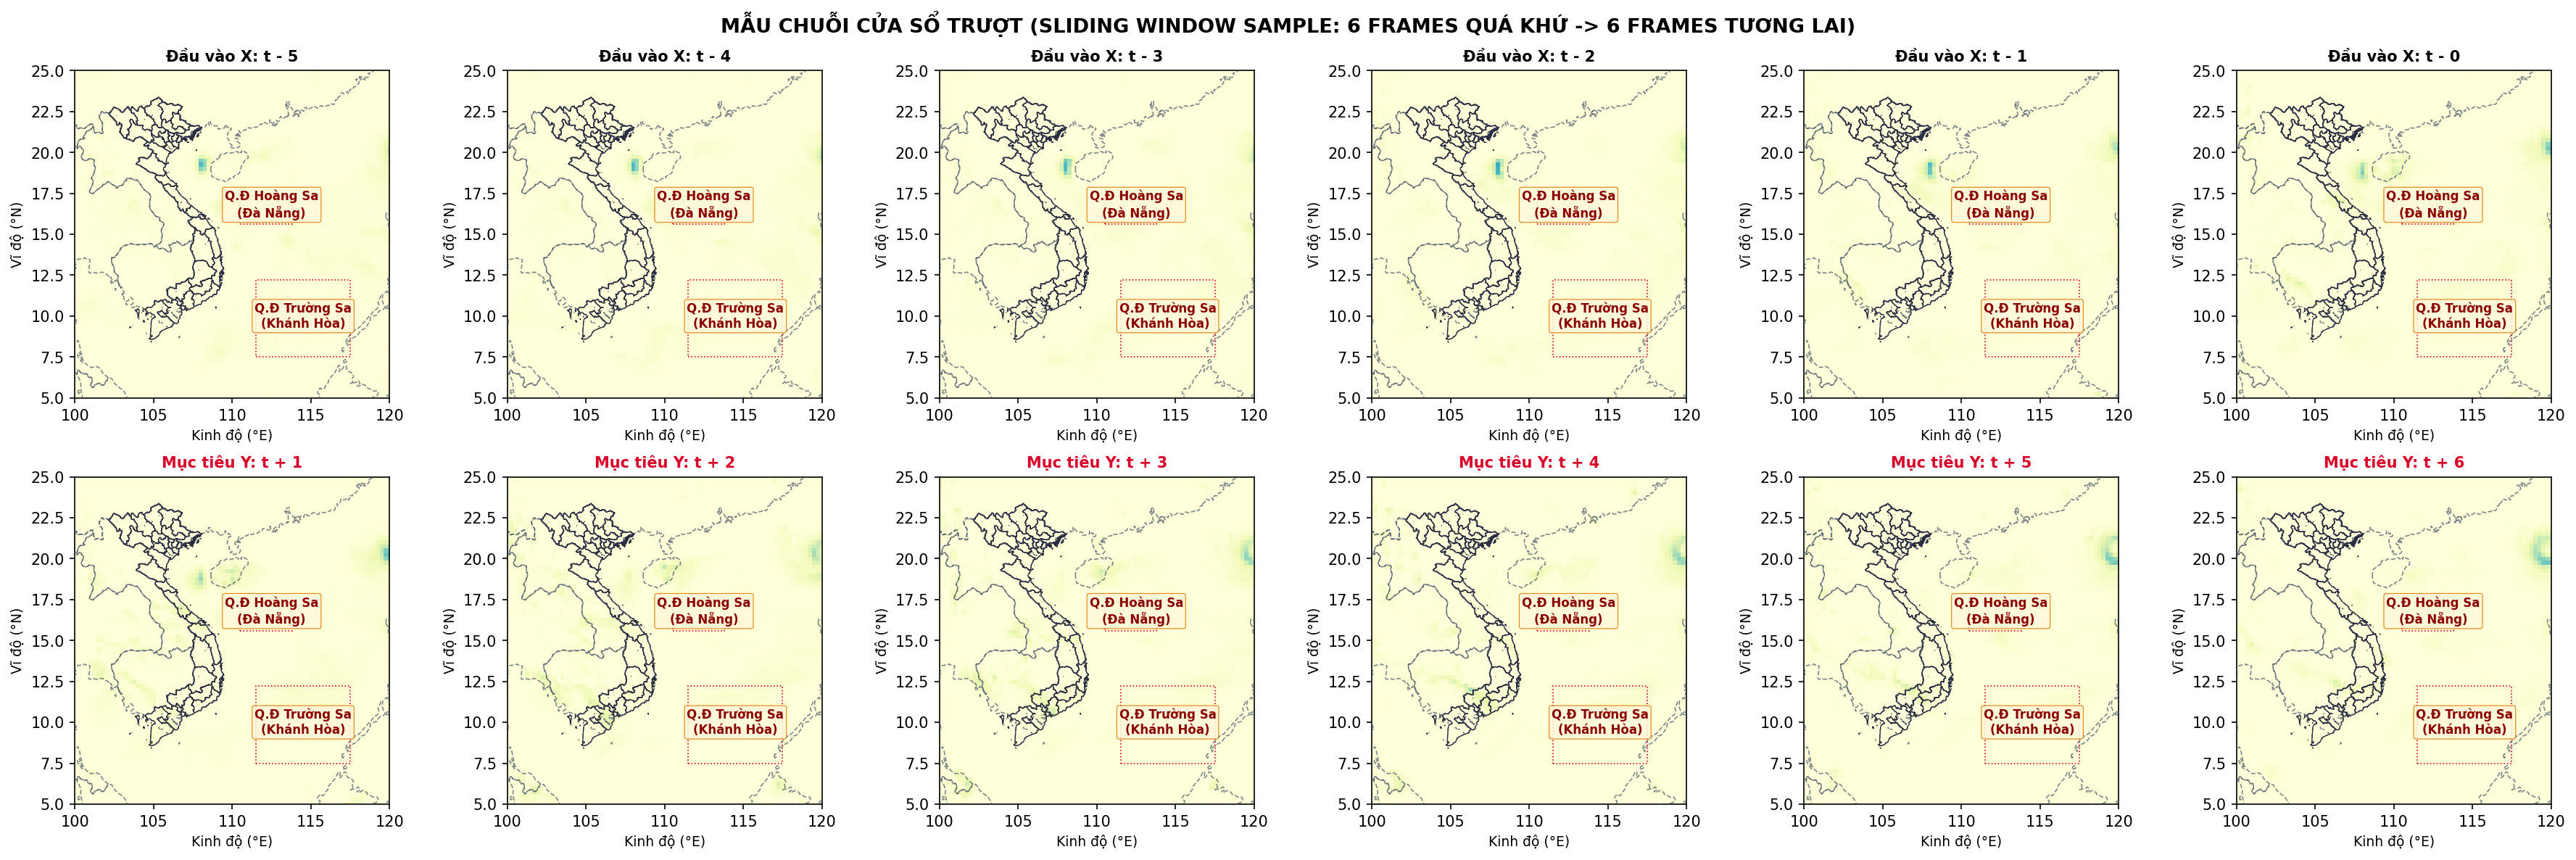

Hoàn tất quy trình tiền xử lý dữ liệu! Dữ liệu sẵn sàng cho các notebook huấn luyện.


In [14]:
# Lấy 1 batch ngẫu nhiên từ train_loader
sample_batch_x, sample_batch_y = next(iter(train_loader))

print(f"Batch X Shape: {sample_batch_x.shape} -> (BatchSize, InSteps, Channels, Lat, Lon)")
print(f"Batch Y Shape: {sample_batch_y.shape} -> (BatchSize, OutSteps, 1, Lat, Lon)")

# Chọn mẫu đầu tiên trong batch để hiển thị
x_vis = sample_batch_x[0].numpy()  # (6, 5, 81, 81)
y_vis = sample_batch_y[0, :, 0].numpy()  # (6, 81, 81)

lons = np.array(metadata['longitudes'])
lats = np.array(metadata['latitudes'])
lons_grid, lats_grid = np.meshgrid(lons, lats)

fig, axes = plt.subplots(2, 6, figsize=(24, 8), dpi=150)

# Hàng 1: 6 frames quá khứ của Lượng mưa (Kênh 0)
for t in range(6):
    ax = axes[0, t]
    im = ax.pcolormesh(lons_grid, lats_grid, x_vis[t, 0], cmap='YlGnBu', vmin=0, vmax=1.0, shading='auto')
    draw_vietnam_map(ax, show_provinces=True, show_islands=True, show_islands_box=True, show_country_labels=False)
    ax.set_title(f"Đầu vào X: t - {5-t}", fontsize=10, fontweight='bold')

# Hàng 2: 6 frames tương lai cần dự báo của Lượng mưa (Y Target)
for t in range(6):
    ax = axes[1, t]
    im = ax.pcolormesh(lons_grid, lats_grid, y_vis[t], cmap='YlGnBu', vmin=0, vmax=1.0, shading='auto')
    draw_vietnam_map(ax, show_provinces=True, show_islands=True, show_islands_box=True, show_country_labels=False)
    ax.set_title(f"Mục tiêu Y: t + {t+1}", fontsize=10, fontweight='bold', color='#D90429')

plt.suptitle("MẪU CHUỖI CỬA SỔ TRƯỢT (SLIDING WINDOW SAMPLE: 6 FRAMES QUÁ KHỨ -> 6 FRAMES TƯƠNG LAI)", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('img/10_sample_sliding_window_batch.png', dpi=200, bbox_inches='tight')
plt.show()

print("Hoàn tất quy trình tiền xử lý dữ liệu! Dữ liệu sẵn sàng cho các notebook huấn luyện.")
